## Загрузка данных и библиотек

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import warnings
from search_for_optimal_parameters import delayed_mutual_information, get_first_local_minimum, false_nearest_neighbors
from visualisation_ccm import viz_ccm
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (10, 6),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

df = pd.read_csv('resnet_cifar_val_poison_logs.csv')

ts_data = {
    'val_loss': df['val_loss'].to_numpy(),
    'val_accuracy': df['val_accuracy'].to_numpy(),
    'poison_fraction': df['poison_fraction'].to_numpy()
}

print(f"Data loaded. Length of time series: {len(df)} steps")

Data loaded. Length of time series: 3920 steps


## Поиск оптимального $\tau$

In [16]:
max_tau_search = 100
dmi_results = {}
optimal_taus = {}

for name, series in ts_data.items():
    taus, dmi_vals = delayed_mutual_information(series, max_tau=max_tau_search, bins=50)
    dmi_results[name] = dmi_vals
    
    min_idx = get_first_local_minimum(dmi_vals, abs_eps=0.02, drop_fraction=0.02)
    optimal_taus[name] = taus[min_idx]

print("Optimal tau values found:")
for k, v in optimal_taus.items():
    print(f"  {k}: tau = {v}")

Optimal tau values found:
  val_loss: tau = 7
  val_accuracy: tau = 5
  poison_fraction: tau = 1


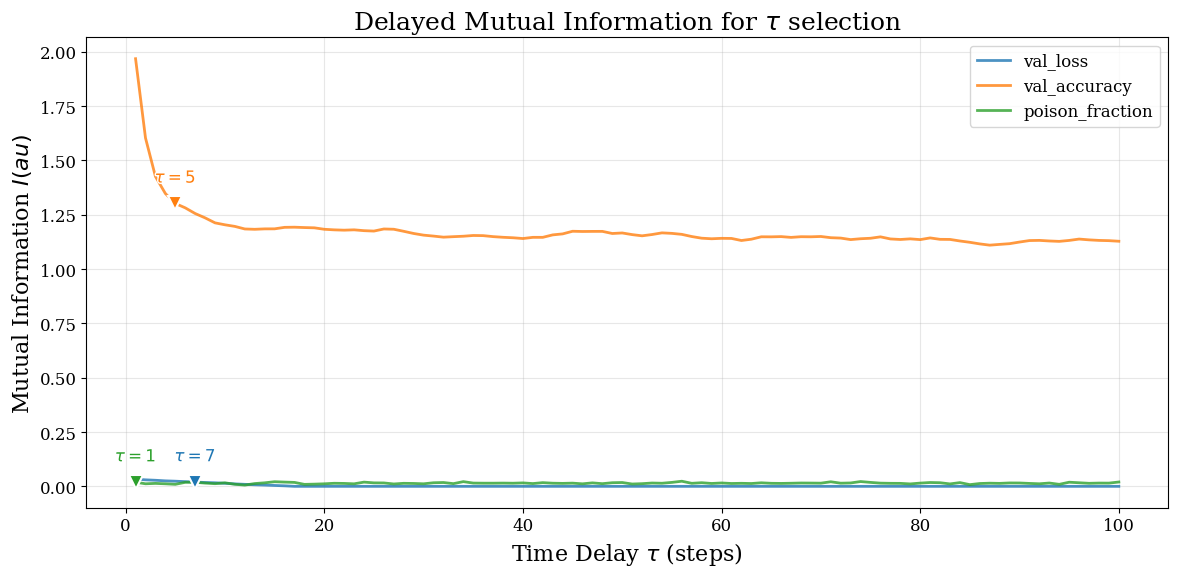

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'val_loss': 'tab:blue', 'val_accuracy': 'tab:orange', 'poison_fraction': 'tab:green'}
text_outline = [path_effects.withStroke(linewidth=2, foreground="white")]

for name, dmi_vals in dmi_results.items():
    taus = np.arange(1, max_tau_search + 1)
    line, = ax.plot(taus, dmi_vals, label=name, color=colors[name], alpha=0.8)
    
    opt_tau = optimal_taus[name]
    opt_dmi = dmi_vals[opt_tau - 1]
    
    ax.plot(opt_tau, opt_dmi, marker='v', markersize=10, 
            color=colors[name], markeredgecolor='white', markeredgewidth=1.5, zorder=10)
    
    ax.annotate(f"$\\tau={opt_tau}$", 
                xy=(opt_tau, opt_dmi), xytext=(0, 15), textcoords="offset points",
                ha='center', fontsize=12, color=colors[name], fontweight='bold',
                path_effects=text_outline, zorder=20)

ax.set_xlabel(r"Time Delay $\tau$ (steps)")
ax.set_ylabel("Mutual Information $I(\tau)$")
ax.set_title("Delayed Mutual Information for $\\tau$ selection")
ax.legend()
plt.tight_layout()
plt.savefig("DMI_tau_selection.pdf", format='pdf', dpi=300)
plt.show()

## Поиск оптимального $E$

In [18]:
m_data = {}
max_m_search = 15

for name, series in ts_data.items():
    tau = optimal_taus[name]
    print(f"Calculating FNN for {name} with tau={tau}...")
    fnn_vals = false_nearest_neighbors(series, tau=tau, max_m=max_m_search)
    m_data[name] = fnn_vals

print("FNN calculation completed.")

Calculating FNN for val_loss with tau=7...
Calculating FNN for val_accuracy with tau=5...
Calculating FNN for poison_fraction with tau=1...
FNN calculation completed.


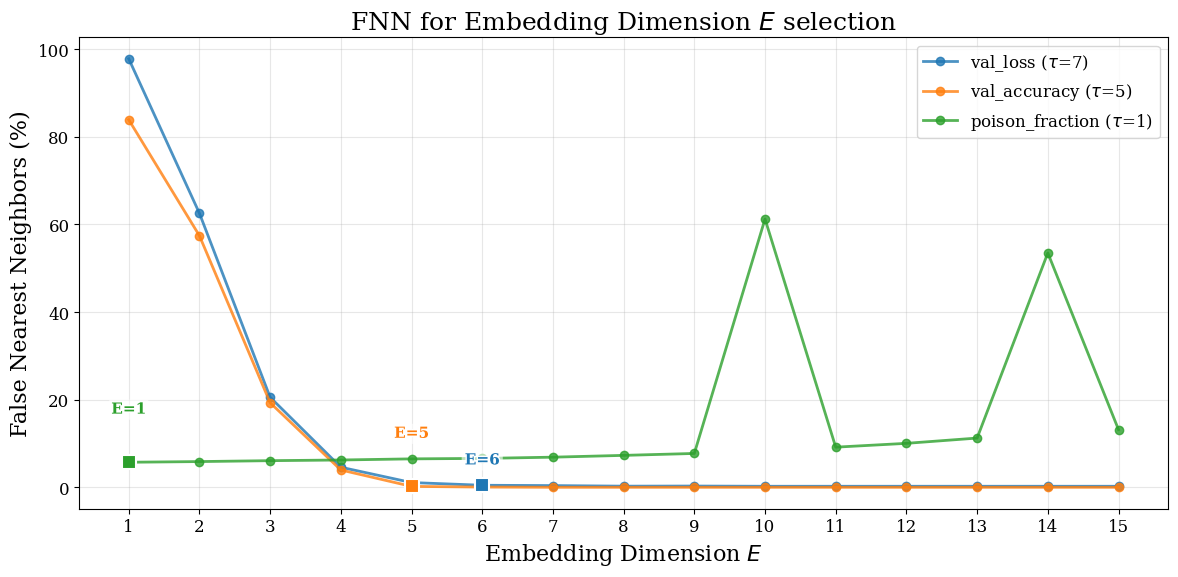

--- Final Parameters for CCM ---
val_loss: tau=7, E=6
val_accuracy: tau=5, E=5
poison_fraction: tau=1, E=1

ИТОГОВОЕ ГЛОБАЛЬНОЕ E ДЛЯ СИСТЕМЫ: 6


In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

text_groups = {}
dims = np.arange(1, max_m_search + 1)

for name, values in m_data.items():
    vals = np.asarray(values)
    
    below_threshold = np.where(vals < 1.0)[0]
    if len(below_threshold) > 0:
        opt_m_idx = below_threshold[0]
    else:
        opt_m_idx = np.argmin(vals)
        
    opt_m = dims[opt_m_idx]
    min_val = vals[opt_m_idx]

    line, = ax.plot(dims, vals, label=f"{name} ($\\tau$={optimal_taus[name]})", 
                    color=colors[name], marker='o', markersize=6, alpha=0.8)
    line_color = line.get_color()

    ax.plot(opt_m, min_val, marker='s', markersize=10, color=line_color,
             markeredgecolor='white', markeredgewidth=1.5, zorder=10)

    txt_label = f"E={opt_m}"
    if opt_m not in text_groups:
        text_groups[opt_m] =[]
    text_groups[opt_m].append({'y': min_val, 'text': txt_label, 'color': line_color})

Y_PROXIMITY_THRESHOLD = 5.0
text_outline =[path_effects.withStroke(linewidth=2, foreground="white")]

for x_val, items in text_groups.items():
    items.sort(key=lambda item: item['y'])
    base_start_offset = 15 if (int(x_val) % 2 == 0) else 35
    current_stack_level = 0
    last_y = -9999

    for item in items:
        if abs(item['y'] - last_y) < Y_PROXIMITY_THRESHOLD:
            current_stack_level += 1
        else:
            current_stack_level = 0

        vertical_offset = base_start_offset + (current_stack_level * 18)
        ax.annotate(item['text'], xy=(x_val, item['y']), xytext=(0, vertical_offset),
            textcoords="offset points", ha='center', fontsize=11, color=item['color'],
            fontweight='bold', zorder=20, path_effects=text_outline,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
        last_y = item['y']

ax.set_xlabel("Embedding Dimension $E$")
ax.set_ylabel("False Nearest Neighbors (%)")
ax.set_title("FNN for Embedding Dimension $E$ selection")
ax.legend(loc='upper right')

import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.savefig("FNN_embedding_dimension_selected.pdf", format='pdf', dpi=300)
plt.show()

optimal_E = {name: int(np.where(vals < 1.0)[0][0] + 1) if len(np.where(vals < 1.0)[0]) > 0 
             else int(np.argmin(vals) + 1) for name, vals in m_data.items()}
print("--- Final Parameters for CCM ---")
for name in ts_data.keys():
    print(f"{name}: tau={optimal_taus[name]}, E={optimal_E[name]}")

E_global = max(optimal_E.values())
print(f"\nИТОГОВОЕ ГЛОБАЛЬНОЕ E ДЛЯ СИСТЕМЫ: {E_global}")

## Анализ конвергенции через CCM

In [20]:
!pip install causal-ccm

Global E = 6, Max tau used for window = 7
Safe starting L = 45
Library range: 61 steps from 45 to 3920


100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [00:53<00:00,  1.13it/s]


Saved CCM plot to ccm_poison_causes_loss.pdf


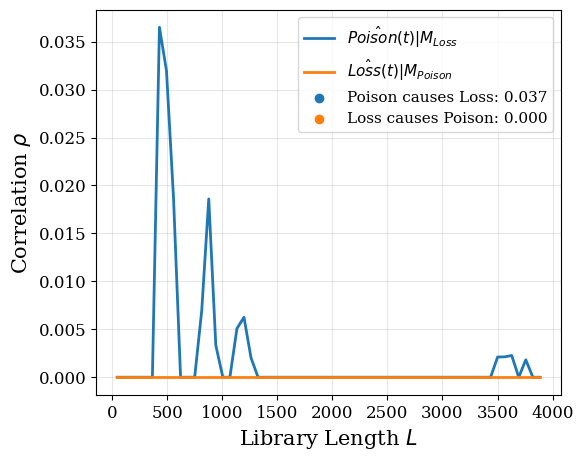

100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [00:53<00:00,  1.15it/s]


Saved CCM plot to ccm_poison_causes_acc.pdf


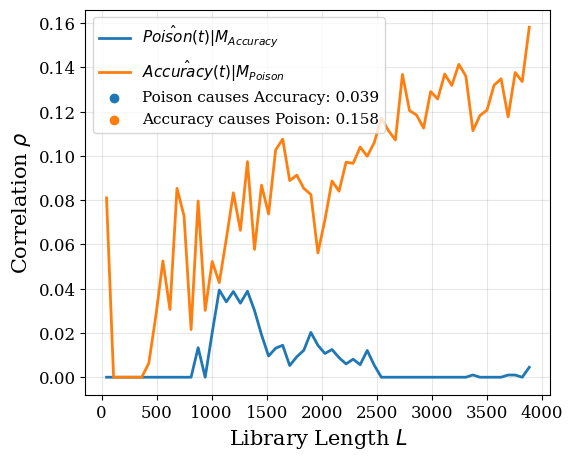

100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [01:07<00:00,  1.11s/it]


Saved CCM plot to ccm_loss_and_acc.pdf


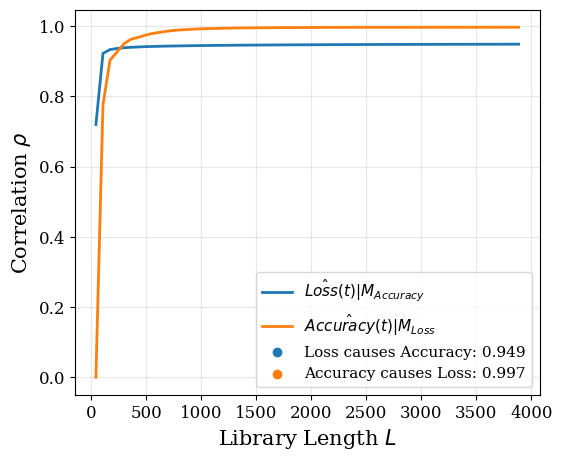

<Axes: xlabel='Library Length $L$', ylabel='Correlation $\\rho$'>

In [22]:
E_ccm = E_global 
N_points = len(ts_data['val_loss'])

max_tau = max(optimal_taus.values())

safe_min_L = (E_ccm - 1) * max_tau + 10

if safe_min_L >= N_points:
    safe_min_L = N_points // 2 

step = max(1, (N_points - safe_min_L) // 60)

L_range = range(safe_min_L, N_points, step)

print(f"Global E = {E_ccm}, Max tau used for window = {max_tau}")
print(f"Safe starting L = {safe_min_L}")
print(f"Library range: {len(L_range)} steps from {L_range.start} to {L_range.stop}")


viz_ccm(
    ccm, 
    X=ts_data['poison_fraction'], 
    Y=ts_data['val_loss'],
    x_name='Poison', 
    y_name='Loss',
    L_range=L_range, 
    tau_x=optimal_taus['poison_fraction'],
    tau_y=optimal_taus['val_loss'],
    E=E_ccm,
    save_path='ccm_poison_causes_loss'
)

viz_ccm(
    ccm, 
    X=ts_data['poison_fraction'], 
    Y=ts_data['val_accuracy'],
    x_name='Poison', 
    y_name='Accuracy',
    L_range=L_range, 
    tau_x=optimal_taus['poison_fraction'], 
    tau_y=optimal_taus['val_accuracy'],
    E=E_ccm,
    save_path='ccm_poison_causes_acc'
)

viz_ccm(
    ccm, 
    X=ts_data['val_loss'], 
    Y=ts_data['val_accuracy'],
    x_name='Loss', 
    y_name='Accuracy',
    L_range=L_range, 
    tau_x=optimal_taus['val_loss'], 
    tau_y=optimal_taus['val_accuracy'],
    E=E_ccm,
    save_path='ccm_loss_and_acc'
)

Global E = 6, Max tau used for window = 1
Safe starting L = 15
Library range: 61 steps from 15 to 3920


100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [00:55<00:00,  1.09it/s]


Saved CCM plot to ccm_poison_causes_loss.pdf


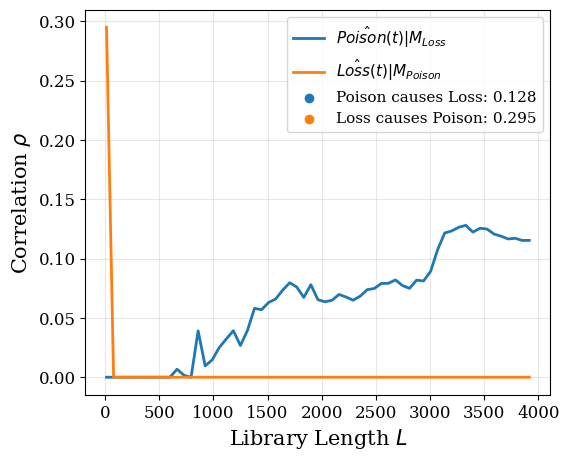

100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [00:55<00:00,  1.10it/s]


Saved CCM plot to ccm_poison_causes_acc.pdf


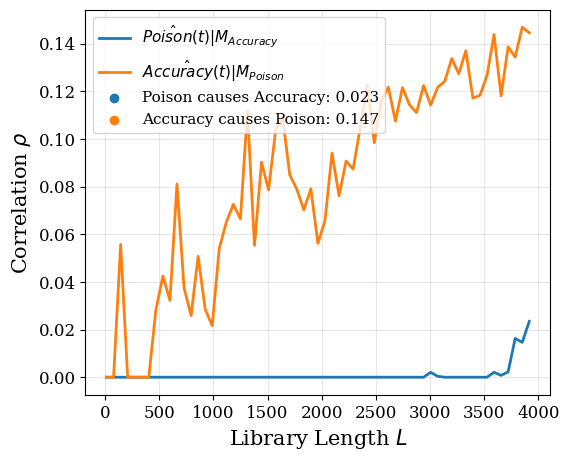

100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [01:10<00:00,  1.15s/it]


Saved CCM plot to ccm_loss_and_acc.pdf


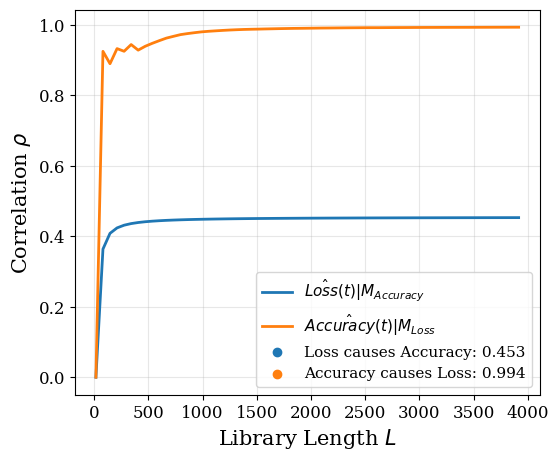

<Axes: xlabel='Library Length $L$', ylabel='Correlation $\\rho$'>

In [23]:
E_ccm = E_global 
N_points = len(ts_data['val_loss'])

max_tau = 1

safe_min_L = (E_ccm - 1) * max_tau + 10

if safe_min_L >= N_points:
    safe_min_L = N_points // 2 

step = max(1, (N_points - safe_min_L) // 60)

L_range = range(safe_min_L, N_points, step)

print(f"Global E = {E_ccm}, Max tau used for window = {max_tau}")
print(f"Safe starting L = {safe_min_L}")
print(f"Library range: {len(L_range)} steps from {L_range.start} to {L_range.stop}")


viz_ccm(
    ccm, 
    X=ts_data['poison_fraction'], 
    Y=ts_data['val_loss'],
    x_name='Poison', 
    y_name='Loss',
    L_range=L_range, 
    tau_x=1,
    tau_y=1,
    E=E_ccm,
    save_path='ccm_poison_causes_loss'
)

viz_ccm(
    ccm, 
    X=ts_data['poison_fraction'], 
    Y=ts_data['val_accuracy'],
    x_name='Poison', 
    y_name='Accuracy',
    L_range=L_range, 
    tau_x=1, 
    tau_y=1,
    E=E_ccm,
    save_path='ccm_poison_causes_acc'
)

viz_ccm(
    ccm, 
    X=ts_data['val_loss'], 
    Y=ts_data['val_accuracy'],
    x_name='Loss', 
    y_name='Accuracy',
    L_range=L_range, 
    tau_x=1, 
    tau_y=1,
    E=E_ccm,
    save_path='ccm_loss_and_acc'
)